# 05) Backtest -- Long/Short Bucket Strategies

Robustness check across three entry snapshot times: the terminal `15:59:59` (one second before close -- trivially easy, near_price is essentially the exchange's own final-second estimate), `15:59:00`, and `15:55:00` (earliest point near_price/far_price are disseminated at all).

## Setup

In [20]:
import json
import tarfile

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import HuberRegressor, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train_df = pd.read_csv("data/train.csv", parse_dates=["date"])
with open("data/columns.json") as f:
    columns = json.load(f)

TARGET_COL = columns["target_cols"][0]
FINAL_FEATURE_COLS = columns["final_feature_cols"]

with open("best_hyperparameters.json") as f:
    best_hyperparameters = json.load(f)

print(f"train_df: {train_df.shape[0]} rows, target = {TARGET_COL!r}")
print(f"{len(FINAL_FEATURE_COLS)} final features:", FINAL_FEATURE_COLS)
print("best_hyperparameters keys:", list(best_hyperparameters.keys()))

train_df: 8443 rows, target = 'target_bps_vs_mid'
4 final features: ['near_price_vs_mid_bps', 'urgency', 'ref_price_vs_mid_bps', 'far_price_vs_mid_bps']
best_hyperparameters keys: ['huber', 'lasso', 'gradient_boosting', 'random_forest', 'mlp']


## Raw intraday loader + snapshot panel builder

Reconstructs the same 4 features + target used everywhere else in this project, but as of an arbitrary wall-clock cutoff instead of the fixed terminal snapshot. `near_price`/`far_price` are `0` in the raw feed whenever Nasdaq hasn't disseminated them yet -- treated as genuinely missing (NaN), matching the existing `far_price_available` convention from `02)`, and left to the modeling pipeline's per-fold median imputer rather than fed in as a literal 0.

In [21]:
def load_raw_intraday(tar_path, valid_keys):
    frames = []
    with tarfile.open(tar_path) as tf:
        for member in tf.getmembers():
            if not member.name.endswith(".csv.gz"):
                continue
            date_str = member.name.split(".")[0]
            d = pd.read_csv(tf.extractfile(member), compression="gzip")
            d = d.drop(columns=["ts.1"])
            d["date"] = pd.to_datetime(date_str, format="%Y%m%d")
            d = d.merge(valid_keys, on=["symbol", "date"], how="inner")
            if len(d):
                frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df["ts"] = pd.to_datetime(df["ts"])
    df["local_clock"] = df["local_time"].str.slice(11, 19)
    return df


valid_keys = train_df[["symbol", "date"]].drop_duplicates()
raw = load_raw_intraday("data/202503_imbalance.tar", valid_keys)
print(f"raw intraday rows (restricted to train universe): {raw.shape[0]}")

raw intraday rows (restricted to train universe): 3302768


In [22]:
def build_snapshot_panel(raw, cutoff_clock):
    sl = raw[raw["local_clock"] <= cutoff_clock]
    snap = sl.sort_values("ts").groupby(["symbol", "date"]).tail(1).copy()

    keys = train_df[["symbol", "date", "close_price"]].drop_duplicates()
    panel = snap.merge(keys, on=["symbol", "date"], how="inner")

    panel["signed_shares"] = np.where(panel["side"] == "BUY", panel["shares"],
                                np.where(panel["side"] == "SELL", -panel["shares"], 0.0))
    panel["signed_imbalance_ratio"] = panel["signed_shares"] / (panel["paired_shares"] + panel["shares"])
    panel["spread_bps"] = (panel["ask"] - panel["bid"]) / panel["ref_price"] * 1e4
    panel["urgency"] = panel["signed_imbalance_ratio"] * panel["spread_bps"]

    mid = (panel["bid"] + panel["ask"]) / 2
    near_available = panel["near_price"] != 0
    far_available = panel["far_price"] != 0
    panel["near_price_vs_mid_bps"] = np.where(near_available, (panel["near_price"] / mid - 1) * 1e4, np.nan)
    panel["far_price_vs_mid_bps"] = np.where(far_available, (panel["far_price"] / mid - 1) * 1e4, np.nan)
    panel["ref_price_vs_mid_bps"] = (panel["ref_price"] / mid - 1) * 1e4

    panel[TARGET_COL] = (panel["close_price"] / mid - 1) * 1e4

    cols = ["date", "symbol"] + FINAL_FEATURE_COLS + [TARGET_COL]
    panel = panel[cols]

    # a handful of names have a genuinely missing bid/ask at some snapshots (no NBBO
    # at that instant, e.g. a brief quote gap) -- the target can't be estimated from a
    # missing quote, so the row is dropped rather than imputed, same as 01)'s existing
    # INSUFFICIENT-side filtering
    n_before = len(panel)
    panel = panel[np.isfinite(panel[TARGET_COL])]
    n_dropped = n_before - len(panel)
    if n_dropped:
        print(f"  dropped {n_dropped} row(s) with a non-finite target (missing bid/ask at snapshot)")

    return panel.reset_index(drop=True)


PANELS = {
    "15:55:00": build_snapshot_panel(raw, "15:55:00"),
    "15:59:00": build_snapshot_panel(raw, "15:59:00"),
    "15:59:59 (terminal)": train_df[["date", "symbol"] + FINAL_FEATURE_COLS + [TARGET_COL]].copy(),
}

for label, panel_df in PANELS.items():
    nan_rates = panel_df[FINAL_FEATURE_COLS].isna().mean()
    print(f"{label}: {panel_df.shape[0]} rows | NaN rates: "
          + ", ".join(f"{c}={r:.1%}" for c, r in nan_rates.items()))

  dropped 1 row(s) with a non-finite target (missing bid/ask at snapshot)
15:55:00: 8442 rows | NaN rates: near_price_vs_mid_bps=0.0%, urgency=0.0%, ref_price_vs_mid_bps=0.0%, far_price_vs_mid_bps=11.9%
15:59:00: 8443 rows | NaN rates: near_price_vs_mid_bps=0.0%, urgency=0.0%, ref_price_vs_mid_bps=0.0%, far_price_vs_mid_bps=0.7%
15:59:59 (terminal): 8443 rows | NaN rates: near_price_vs_mid_bps=0.0%, urgency=0.0%, ref_price_vs_mid_bps=0.0%, far_price_vs_mid_bps=0.3%


## Walk-forward folds (per panel)

In [23]:
def build_folds(panel_df, min_train_days=1, delta_days=1):
    unique_dates = np.sort(panel_df["date"].unique())
    folds = []
    for eval_start in range(min_train_days, len(unique_dates), delta_days):
        fit_dates = unique_dates[:eval_start]
        eval_dates = unique_dates[eval_start:eval_start + delta_days]
        assert fit_dates.max() < eval_dates.min(), "eval dates must all fall after fit dates"
        fit_mask = panel_df["date"].isin(fit_dates)
        eval_mask = panel_df["date"].isin(eval_dates)
        folds.append((fit_mask, eval_mask))
    return folds

print("build_folds ready")

build_folds ready


## Bucket construction and PnL helpers

In [24]:
BUCKET_SCHEMES = {
    "decile": 0.10,
    "quintile": 0.20,
    "quartile": 0.25,
    "50_50": 0.50,
}


def bucket_pnl(eval_df, pred_col, target_col, frac):
    n = len(eval_df)
    n_bucket = max(1, int(round(n * frac)))
    ranked = eval_df.sort_values(pred_col, ascending=False)
    long_leg = ranked.iloc[:n_bucket]
    short_leg = ranked.iloc[-n_bucket:]
    long_ret = long_leg[target_col].mean()
    short_ret = short_leg[target_col].mean()
    return {
        "long_ret": long_ret,
        "short_ret": short_ret,
        "spread": long_ret - short_ret,
        "n_long": len(long_leg),
        "n_short": len(short_leg),
        "n_total": n,
    }

print("bucket helpers ready")

bucket helpers ready


## Reusable backtest runners

Same sklearn Pipeline / PyTorch MLP logic as before, now wrapped as functions so they can be run once per snapshot-time panel instead of duplicated.

In [25]:
MODEL_CLASSES = {
    "huber": HuberRegressor,
    "lasso": Lasso,
    "gradient_boosting": GradientBoostingRegressor,
    "random_forest": RandomForestRegressor,
}


def run_sklearn_backtest(panel_df, folds, snapshot_label):
    records = []
    for model_name, estimator_class in MODEL_CLASSES.items():
        params = dict(best_hyperparameters[model_name])
        if "random_state" in estimator_class().get_params():
            params["random_state"] = 0

        pipeline = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", estimator_class(**params)),
        ])

        for fold_idx, (fit_mask, eval_mask) in enumerate(folds):
            X_fit = panel_df.loc[fit_mask, FINAL_FEATURE_COLS]
            y_fit = panel_df.loc[fit_mask, TARGET_COL]
            X_eval = panel_df.loc[eval_mask, FINAL_FEATURE_COLS]

            pipeline.fit(X_fit, y_fit)
            pred_eval = pipeline.predict(X_eval)

            eval_df = panel_df.loc[eval_mask, ["date", "symbol", TARGET_COL]].copy()
            eval_df["pred"] = pred_eval
            eval_date = eval_df["date"].iloc[0]

            for scheme_name, frac in BUCKET_SCHEMES.items():
                result = bucket_pnl(eval_df, "pred", TARGET_COL, frac)
                records.append({"snapshot_time": snapshot_label, "model": model_name,
                                 "fold": fold_idx, "date": eval_date,
                                 "bucket_scheme": scheme_name, **result})
    return records

print("run_sklearn_backtest ready")

run_sklearn_backtest ready


In [26]:
import torch
import torch.nn as nn

ACTIVATIONS = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU}


class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_layer_sizes, activation):
        super().__init__()
        act_cls = ACTIVATIONS[activation]
        layers = []
        prev_size = input_dim
        for size in hidden_layer_sizes:
            layers.append(nn.Linear(prev_size, size))
            layers.append(act_cls())
            prev_size = size
        layers.append(nn.Linear(prev_size, 1))  # linear output, no activation
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_one_fold_torch(X_fit, y_fit, X_eval, y_eval, hidden_layer_sizes, activation,
                          alpha, learning_rate_init, max_epochs=200, patience=20):
    device = torch.device("cpu")
    X_fit_t = torch.tensor(X_fit, dtype=torch.float32, device=device)
    y_fit_t = torch.tensor(y_fit, dtype=torch.float32, device=device)
    X_eval_t = torch.tensor(X_eval, dtype=torch.float32, device=device)
    y_eval_t = torch.tensor(y_eval, dtype=torch.float32, device=device)

    model = MLPNet(X_fit.shape[1], tuple(hidden_layer_sizes), activation).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate_init, weight_decay=alpha)
    loss_fn = nn.MSELoss()

    best_eval_mse = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_fit_t), y_fit_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            eval_mse = loss_fn(model(X_eval_t), y_eval_t).item()

        if eval_mse < best_eval_mse:
            best_eval_mse = eval_mse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_fit = model(X_fit_t).numpy()
        pred_eval = model(X_eval_t).numpy()
    return pred_fit, pred_eval

print("MLPNet and train_one_fold_torch ready")

MLPNet and train_one_fold_torch ready


In [27]:
def run_mlp_backtest(panel_df, folds, snapshot_label):
    mlp_params = best_hyperparameters["mlp"]
    records = []

    for fold_idx, (fit_mask, eval_mask) in enumerate(folds):
        X_fit_raw = panel_df.loc[fit_mask, FINAL_FEATURE_COLS].to_numpy()
        y_fit = panel_df.loc[fit_mask, TARGET_COL].to_numpy()
        X_eval_raw = panel_df.loc[eval_mask, FINAL_FEATURE_COLS].to_numpy()
        y_eval = panel_df.loc[eval_mask, TARGET_COL].to_numpy()

        imputer = SimpleImputer(strategy="median").fit(X_fit_raw)
        X_fit_imp = imputer.transform(X_fit_raw)
        X_eval_imp = imputer.transform(X_eval_raw)
        scaler = StandardScaler().fit(X_fit_imp)
        X_fit_scaled = scaler.transform(X_fit_imp)
        X_eval_scaled = scaler.transform(X_eval_imp)

        _, pred_eval = train_one_fold_torch(
            X_fit_scaled, y_fit, X_eval_scaled, y_eval,
            hidden_layer_sizes=mlp_params["hidden_layer_sizes"],
            activation=mlp_params["activation"],
            alpha=mlp_params["alpha"],
            learning_rate_init=mlp_params["learning_rate_init"],
        )

        eval_df = panel_df.loc[eval_mask, ["date", "symbol", TARGET_COL]].copy()
        eval_df["pred"] = pred_eval
        eval_date = eval_df["date"].iloc[0]

        for scheme_name, frac in BUCKET_SCHEMES.items():
            result = bucket_pnl(eval_df, "pred", TARGET_COL, frac)
            records.append({"snapshot_time": snapshot_label, "model": "mlp",
                             "fold": fold_idx, "date": eval_date,
                             "bucket_scheme": scheme_name, **result})
    return records

print("run_mlp_backtest ready")

run_mlp_backtest ready


## Run the backtest across all three snapshot times

In [28]:
all_records = []
for label, panel_df in PANELS.items():
    folds = build_folds(panel_df)
    all_records += run_sklearn_backtest(panel_df, folds, label)
    all_records += run_mlp_backtest(panel_df, folds, label)
    print(f"{label}: backtested {len(folds)} folds")

results_df = pd.DataFrame(all_records)
print(f"\n{len(results_df)} total (snapshot_time, model, fold, bucket_scheme) records")

15:55:00: backtested 16 folds
15:59:00: backtested 16 folds
15:59:59 (terminal): backtested 16 folds

960 total (snapshot_time, model, fold, bucket_scheme) records


## Aggregate results

Sharpe is computed on the daily spread series (non-overlapping, one observation per out-of-sample day). `sharpe_annualized` scales by √252 by convention -- with at most 16 out-of-sample days this is a rough scale reference, not a robust estimate.

In [29]:
summary = results_df.groupby(["snapshot_time", "model", "bucket_scheme"]).agg(
    mean_daily_spread_bps=("spread", "mean"),
    std_daily_spread_bps=("spread", "std"),
    hit_rate=("spread", lambda s: (s > 0).mean()),
    n_days=("spread", "count"),
    cumulative_spread_bps=("spread", "sum"),
).reset_index()

summary["sharpe_daily"] = summary["mean_daily_spread_bps"] / summary["std_daily_spread_bps"]
summary["sharpe_annualized"] = summary["sharpe_daily"] * np.sqrt(252)
summary = summary.sort_values(["bucket_scheme", "model", "snapshot_time"]).reset_index(drop=True)

pd.set_option("display.width", 160)
print(summary.to_string(index=False))

      snapshot_time             model bucket_scheme  mean_daily_spread_bps  std_daily_spread_bps  hit_rate  n_days  cumulative_spread_bps  sharpe_daily  sharpe_annualized
           15:55:00 gradient_boosting         50_50              11.946860              5.577326       1.0      16             191.149757      2.142041          34.003841
           15:59:00 gradient_boosting         50_50               6.781708              2.060319       1.0      16             108.507324      3.291582          52.252240
15:59:59 (terminal) gradient_boosting         50_50               7.221489              1.024952       1.0      16             115.543832      7.045682         111.846736
           15:55:00             huber         50_50              14.243839              6.088658       1.0      16             227.901429      2.339405          37.136908
           15:59:00             huber         50_50               7.068634              2.240499       1.0      16             113.098146      3.

## Robustness comparison: does performance survive trading earlier than the last second?

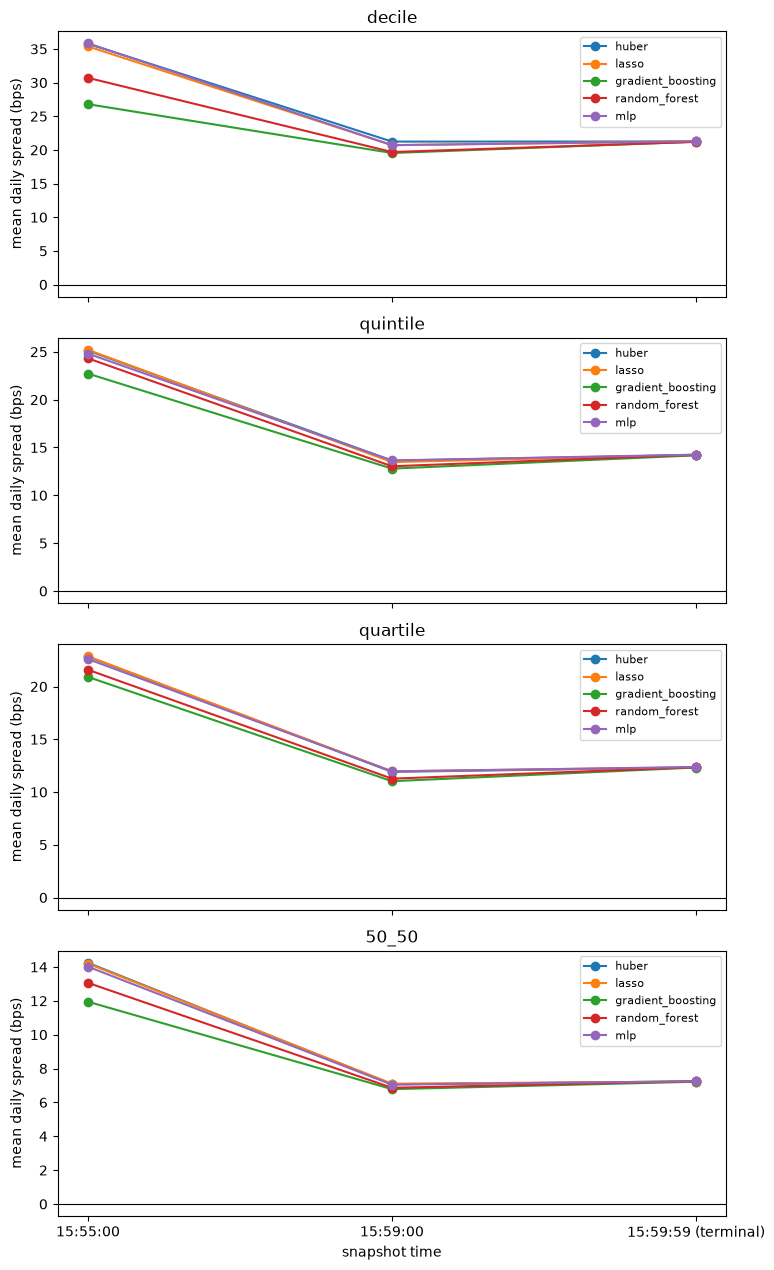

In [30]:
import matplotlib.pyplot as plt

snapshot_order = list(PANELS.keys())
model_order = list(MODEL_CLASSES.keys()) + ["mlp"]

fig, axes = plt.subplots(len(BUCKET_SCHEMES), 1, figsize=(8, 3.2 * len(BUCKET_SCHEMES)), sharex=True)

for ax, scheme_name in zip(axes, BUCKET_SCHEMES):
    sub = summary[summary["bucket_scheme"] == scheme_name]
    for model_name in model_order:
        s = sub[sub["model"] == model_name].set_index("snapshot_time").reindex(snapshot_order)
        ax.plot(snapshot_order, s["mean_daily_spread_bps"], marker="o", label=model_name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(scheme_name)
    ax.set_ylabel("mean daily spread (bps)")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("snapshot time")
fig.tight_layout()
plt.show()